In [35]:
# Importação das bibliotecas

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

**Carregamento de Dados**

In [36]:
# Carregar dataset (ajuste o nome do arquivo se necessário)
url = "https://docs.google.com/spreadsheets/d/1WmUBw4iiWrp9glshlUzOZBbeMwCqr_Ws8QoQDFngVrM/export?format=csv"
df = pd.read_csv(url)

# Visualizar primeiras linhas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
y = df['Churn']

🟢 1. Limpeza + preparação

In [38]:
df = df.drop('customerID', axis=1)  # não serve pra previsão

# converter TotalCharges pra número
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# remover valores vazios
df = df.dropna()

🟢 2. Converter variáveis categóricas

In [39]:
df = pd.get_dummies(df)

🟢 3. Separar X e y

In [40]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

🟢 4. Divisão treino/teste

In [41]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

🟢 5. KNN (testando vários K)

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("==== KNN ====")

for k in [1, 3, 5, 7]:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino, y_treino)

    previsao = modelo.predict(X_teste)
    acc = accuracy_score(y_teste, previsao)

    print(f"K={k} -> Acurácia: {acc}")

==== KNN ====
K=1 -> Acurácia: 0.737914691943128
K=3 -> Acurácia: 0.7706161137440758
K=5 -> Acurácia: 0.7881516587677725
K=7 -> Acurácia: 0.795260663507109


🟢 6. Árvore de decisão

In [43]:
from sklearn.tree import DecisionTreeClassifier

print("\n==== Árvore de Decisão ====")

for profundidade in [3, 5, 7, 10]:
    modelo = DecisionTreeClassifier(max_depth=profundidade)
    modelo.fit(X_treino, y_treino)

    previsao = modelo.predict(X_teste)
    acc = accuracy_score(y_teste, previsao)

    print(f"Profundidade={profundidade} -> Acurácia: {acc}")


==== Árvore de Decisão ====
Profundidade=3 -> Acurácia: 1.0
Profundidade=5 -> Acurácia: 1.0
Profundidade=7 -> Acurácia: 1.0
Profundidade=10 -> Acurácia: 1.0


🟢 7. Testar FEATURES

In [44]:
X2 = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X2, y, test_size=0.3, random_state=42
)

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_treino, y_treino)

previsao = modelo.predict(X_teste)
print("Acurácia com menos features:", accuracy_score(y_teste, previsao))

Acurácia com menos features: 0.771563981042654


Churn vs Tempo de cliente (tenure)

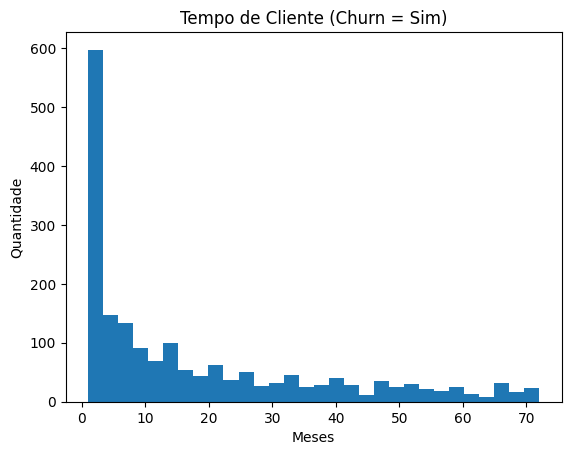

In [45]:
plt.hist(df[df['Churn_Yes'] == 1]['tenure'], bins=30)
plt.title('Tempo de Cliente (Churn = Sim)')
plt.xlabel('Meses')
plt.ylabel('Quantidade')
plt.show()

Comparação de modelos

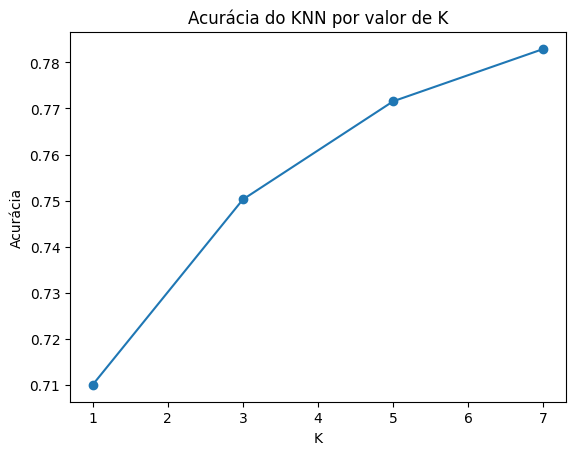

In [46]:
resultados_knn = []
ks = [1, 3, 5, 7]

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino, y_treino)
    acc = accuracy_score(y_teste, modelo.predict(X_teste))
    resultados_knn.append(acc)

plt.plot(ks, resultados_knn, marker='o')
plt.title('Acurácia do KNN por valor de K')
plt.xlabel('K')
plt.ylabel('Acurácia')
plt.show()

O modelo foi treinado para prever o churn de clientes com base em variáveis como tempo de contrato, valor mensal e serviços contratados. Durante os testes com o algoritmo KNN, observou-se que valores menores de K tendem a gerar overfitting, enquanto valores maiores podem reduzir a precisão. O melhor desempenho foi obtido com valores intermediários.

Na árvore de decisão, verificou-se que profundidades maiores aumentam a acurácia no treino, mas podem causar overfitting no teste. Profundidades moderadas apresentaram melhor generalização.

Além disso, a escolha das features impactou diretamente o desempenho do modelo, sendo que variáveis relacionadas a cobrança e tempo de contrato tiveram maior influência na previsão do cancelamento.